# 🛡️ CodeSecAudit-RAG: Dataset Exploration & AI Security Reviewer Prototype

**Author:** Om Choksi
**Notebook Phase:** Phase 2 — Notebook Experimentation & Core Logic
*(of the larger Enterprise Code Review & Security Auditor Agent roadmap)*

---

### 🎯 What this notebook proves

This notebook is **not** a generic Kaggle EDA notebook. It is the experimentation phase of a larger, production-bound system —
an **Enterprise Code Review & Security Auditor Agent** — where a developer pastes code and an AI pipeline scans it,
detects vulnerabilities, retrieves secure-coding guidance, explains the risk, and suggests a fix.

Here, we prove the **core dataset + RAG + reviewer logic** end-to-end:

| Step | What we do |
|---|---|
| 1 | Load **`CodeSecAudit-RAG`** — a real, self-curated, published dataset (Hugging Face) |
| 2 | Explore dataset quality, sources, and label distributions |
| 3 | Build a **RAG knowledge base** from the OWASP Cheat Sheet Series |
| 4 | Use `all-MiniLM-L6-v2` embeddings + **ChromaDB** for semantic retrieval |
| 5 | Run a lightweight **Critic → Retriever → Fixer** prototype on real vulnerable code |
| 6 | Lay out the path from notebook → CLI → FastAPI → Streamlit → GitHub PR bot → Docker |

### 📦 Dataset: `OMCHOKSI108/CodeSecAudit-RAG`

```
review_combined/train.jsonl.gz        22,827 records
review_combined/validation.jsonl.gz    2,846 records
review_combined/test.jsonl.gz          2,875 records
rag/rag_corpus.jsonl.gz                2,833 chunks  (OWASP Cheat Sheet Series)
```

**Review dataset schema:** `source_name`, `is_vulnerable`, `input_code`, `cwe_id`, `owasp_category`, `severity`, `vulnerability_name`

**RAG corpus schema:** `content`, `source_file`, `title`, `section_title`, `cwe_id`, `vulnerability_name`, `owasp_category`

**Review dataset sources**
- **CodeXGLUE Defect Detection** — large-scale binary vulnerable/non-vulnerable C code. CWE labels are mostly `unknown`
  because the source only provides a binary label — this is expected, not a data-quality bug.
- **OWASP Benchmark (Python)** — CWE-labeled SAST examples (SQL Injection, XSS, Code Injection, Command Injection,
  Path Traversal, Weak Hashing, and more).

**RAG corpus source**
- **OWASP Cheat Sheet Series**, chunked into ~2,833 retrieval-ready passages covering ~16 CWE/security topics
  (avg. chunk size ≈ 869 characters).

### ⚠️ Defensive-use notice
This project is strictly **defensive**. It detects, explains, and remediates vulnerabilities — it does **not** generate
exploit payloads or teach offensive exploitation techniques.

### 🗺️ Where this fits in the bigger picture

```
Notebook prototype  →  CLI reviewer  →  FastAPI API  →  Streamlit UI  →  GitHub PR bot  →  Docker deployment
```

Let's get started.

## 1. Install Dependencies

Lightweight, open-source-only stack. No paid LLM API keys are required for this version of the notebook.

In [1]:
# !pip install -q datasets pandas numpy matplotlib plotly sentence-transformers chromadb
# !pip install --upgrade opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp


## 2. Imports and Global Configuration

In [2]:
import os
import re
import json
import gzip
import textwrap
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
pio.templates.default = "plotly_white"

SEED = 42
np.random.seed(SEED)

# Hugging Face dataset repo
HF_REPO = "OMCHOKSI108/CodeSecAudit-RAG"
HF_BASE_URL = f"https://huggingface.co/datasets/{HF_REPO}/resolve/main"

TRAIN_PATH = f"{HF_BASE_URL}/review_combined/train.jsonl.gz"
VAL_PATH   = f"{HF_BASE_URL}/review_combined/validation.jsonl.gz"
TEST_PATH  = f"{HF_BASE_URL}/review_combined/test.jsonl.gz"
RAG_PATH   = f"{HF_BASE_URL}/rag/rag_corpus.jsonl.gz"

# Cap for the RAG index build (set to None to embed all 2,833 chunks)
MAX_RAG_DOCS = 1000

print("Config loaded. Target dataset:", HF_REPO)

Config loaded. Target dataset: OMCHOKSI108/CodeSecAudit-RAG


### 2.1 Dataset Schema Constants

Named once, here, so every downstream cell refers to the *real* column names instead of guessing.

- **Review dataset** (`df_train` / `df_val` / `df_test`): `source_name`, `is_vulnerable`, `input_code`, `cwe_id`, `owasp_category`, `severity`, `vulnerability_name`
- **RAG corpus** (`df_rag`): `content`, `source_file`, `title`, `section_title`, `cwe_id`, `vulnerability_name`, `owasp_category`

In [3]:
# Review dataset columns
SOURCE_COL = "source_name"
LABEL_COL = "is_vulnerable"
CODE_COL = "input_code"
CWE_COL = "cwe_id"
OWASP_CATEGORY_COL = "owasp_category"
SEVERITY_COL = "severity"
VULN_NAME_COL = "vulnerability_name"

# RAG corpus columns
RAG_CONTENT_COL = "content"
RAG_SOURCE_FILE_COL = "source_file"
RAG_TITLE_COL = "title"
RAG_SECTION_COL = "section_title"
RAG_CWE_COL = "cwe_id"
RAG_VULN_NAME_COL = "vulnerability_name"
RAG_OWASP_CATEGORY_COL = "owasp_category"

print("Schema constants set.")

Schema constants set.


## 3. Load Dataset from Hugging Face

We load the **final, already-curated** dataset directly — this notebook does not rebuild raw data from scratch.

In [4]:
def load_jsonl_gz(url_or_path):
    """Load a .jsonl.gz file from a URL or local path into a list of dicts."""
    import urllib.request
    if url_or_path.startswith("http"):
        local_tmp = "/tmp/" + url_or_path.split("/")[-1]
        if not os.path.exists(local_tmp):
            urllib.request.urlretrieve(url_or_path, local_tmp)
        path = local_tmp
    else:
        path = url_or_path

    records = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

In [5]:
train_records = load_jsonl_gz(TRAIN_PATH)
val_records   = load_jsonl_gz(VAL_PATH)
test_records  = load_jsonl_gz(TEST_PATH)
rag_records   = load_jsonl_gz(RAG_PATH)

df_train = pd.DataFrame(train_records)
df_val   = pd.DataFrame(val_records)
df_test  = pd.DataFrame(test_records)
df_rag   = pd.DataFrame(rag_records)

print("Train:", df_train.shape)
print("Validation:", df_val.shape)
print("Test:", df_test.shape)
print("RAG corpus:", df_rag.shape)

Train: (22827, 19)
Validation: (2846, 19)
Test: (2875, 19)
RAG corpus: (2833, 19)


## 4. Dataset Overview

A quick structural look before diving into distributions: split sizes, total records, RAG corpus size, and schema.

In [6]:
overview = pd.DataFrame({
    "split": ["train", "validation", "test", "rag_corpus"],
    "records": [len(df_train), len(df_val), len(df_test), len(df_rag)]
})
overview.loc[len(overview)] = ["TOTAL (review)", len(df_train) + len(df_val) + len(df_test)]
overview

,split,records
0,train,22827
1,validation,2846
2,test,2875
3,rag_corpus,2833
4,TOTAL (review),28548


In [7]:
print("Review dataset columns:")
print(list(df_train.columns))
print()
print("RAG corpus columns:")
print(list(df_rag.columns))

Review dataset columns:
['id', 'source_name', 'source_type', 'source_split', 'original_id', 'language', 'framework', 'task', 'cwe_id', 'owasp_category', 'severity', 'is_vulnerable', 'vulnerability_name', 'input_code', 'fixed_code', 'explanation', 'secure_pattern', 'tags', 'metadata']

RAG corpus columns:
['id', 'source_name', 'source_type', 'doc_type', 'source_file', 'title', 'section_title', 'chunk_index', 'language', 'framework', 'task', 'cwe_id', 'vulnerability_name', 'owasp_category', 'content', 'positive_pattern', 'negative_pattern', 'tags', 'metadata']


## 5. Data Exploration

We explore the review dataset across source, language, label, CWE, severity, and OWASP category — using interactive
Plotly charts so the notebook reads well for recruiters and reviewers, not just for us.

A quick note before we start: **`unknown` CWE values are expected** for CodeXGLUE records, since that source only
provides a binary vulnerable/clean label with no CWE annotation. OWASP Benchmark Python is what adds real CWE labels
to the dataset.

In [8]:
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_all["split"] = (["train"] * len(df_train)) + (["validation"] * len(df_val)) + (["test"] * len(df_test))
df_all.head(3)

,id,source_name,source_type,source_split,original_id,language,framework,task,cwe_id,owasp_category,severity,is_vulnerable,vulnerability_name,input_code,fixed_code,explanation,secure_pattern,tags,metadata,split
0,codexglue_train_007726,CodeXGLUE Defect Detection,public_dataset,train,9603,c,generic,vulnerability_detection,unknown,unknown,unknown,True,unknown_defect_or_vulnerability,"static inline av_flatten int get_symbol_inline(RangeCoder *c, uint8_t *state,\n\n ...",,This example comes from CodeXGLUE defect detection. The original dataset provides a binary target label but does not...,,"[codexglue, defect-detection, c-language, binary-label]","{'original_target': True, 'project': 'FFmpeg', 'commit_id': '8630b2cd36c57918acfe18302fe77d1ceefbd676', 'normalized_...",train
1,codexglue_train_014476,CodeXGLUE Defect Detection,public_dataset,train,18073,c,generic,vulnerability_detection,unknown,unknown,unknown,True,unknown_defect_or_vulnerability,static int get_last_needed_nal(H264Context *h)\n\n{\n\n int nals_needed = 0;\n\n int i;\n\n\n\n for (i = 0;...,,This example comes from CodeXGLUE defect detection. The original dataset provides a binary target label but does not...,,"[codexglue, defect-detection, c-language, binary-label]","{'original_target': True, 'project': 'FFmpeg', 'commit_id': '76f7e70aa04fc5dbef5242b11cbf8fe4499f61d4', 'normalized_...",train
2,codexglue_train_015862,CodeXGLUE Defect Detection,public_dataset,train,19817,c,generic,vulnerability_detection,unknown,unknown,unknown,True,unknown_defect_or_vulnerability,void pcie_aer_root_init(PCIDevice *dev)\n\n{\n\n uint16_t pos = dev->exp.aer_cap;\n\n\n\n pci_set_long(dev->wm...,,This example comes from CodeXGLUE defect detection. The original dataset provides a binary target label but does not...,,"[codexglue, defect-detection, c-language, binary-label]","{'original_target': True, 'project': 'qemu', 'commit_id': '0e180d9c8a7429c55d23d2e7855f1e490a063aaa', 'normalized_at...",train


In [9]:
fig = px.bar(
    overview[overview["split"] != "TOTAL (review)"],
    x="split", y="records", color="split", text="records",
    title="Dataset Split Sizes"
)
fig.update_traces(textposition="outside")
fig.show()

In [10]:
src_counts = df_all[SOURCE_COL].value_counts().reset_index()
src_counts.columns = ["source_name", "count"]
fig = px.bar(src_counts, x="source_name", y="count", color="source_name", text="count",
             title="Record Source Distribution (CodeXGLUE vs OWASP Benchmark Python)")
fig.update_traces(textposition="outside")
fig.show()

In [11]:
if "language" in df_all.columns:
    lang_counts = df_all["language"].value_counts().reset_index()
    lang_counts.columns = ["language", "count"]
    fig = px.pie(lang_counts, names="language", values="count",
                 title="Language Distribution", hole=0.35)
    fig.show()

In [12]:
# is_vulnerable is already boolean — no string-matching needed
label_counts = df_all[LABEL_COL].astype(bool).value_counts().reset_index()
label_counts.columns = ["is_vulnerable", "count"]
fig = px.bar(label_counts, x="is_vulnerable", y="count", color="is_vulnerable", text="count",
             title="Vulnerable vs Clean Distribution")
fig.update_traces(textposition="outside")
fig.show()

In [13]:
cwe_counts = df_all[CWE_COL].fillna("unknown").astype(str).value_counts().head(15).reset_index()
cwe_counts.columns = ["cwe_id", "count"]
fig = px.bar(cwe_counts.sort_values("count"), x="count", y="cwe_id", orientation="h",
             title="Top 15 CWE IDs (including 'unknown' from CodeXGLUE)", text="count")
fig.update_traces(textposition="outside")
fig.show()

In [14]:
sev_counts = df_all[SEVERITY_COL].fillna("unspecified").astype(str).value_counts().reset_index()
sev_counts.columns = ["severity", "count"]
fig = px.bar(sev_counts, x="severity", y="count", color="severity", text="count",
             title="Severity Distribution")
fig.update_traces(textposition="outside")
fig.show()

In [15]:
owasp_counts = df_all[OWASP_CATEGORY_COL].fillna("unknown").astype(str).value_counts().head(15).reset_index()
owasp_counts.columns = ["owasp_category", "count"]
fig = px.bar(owasp_counts.sort_values("count"), x="count", y="owasp_category", orientation="h",
             title="OWASP Category Distribution", text="count")
fig.update_traces(textposition="outside")
fig.show()

**Why `unknown` CWE dominates part of the dataset:** CodeXGLUE Defect Detection was designed for binary
vulnerable/non-vulnerable classification on C code, so it never carried CWE metadata in the first place — `unknown`
here is a faithful representation of the source, not missing data. OWASP Benchmark Python is the CWE-labeled
complement that lets the Critic component map code patterns to specific CWE IDs.

## 6. Sample Records

A look at one record from each meaningful slice of the dataset, pretty-printed for readability.

In [16]:
def show_record(row, title):
    print("=" * 90)
    print(title)
    print("=" * 90)
    code_field = row.get(CODE_COL, "")
    meta = {k: v for k, v in row.items() if k != CODE_COL}
    print("Metadata:", json.dumps(meta, indent=2, default=str)[:600])
    print("-" * 90)
    print(textwrap.shorten(str(code_field), width=600, placeholder=" ...[truncated]"))
    print()

In [17]:
codexglue_mask = df_all[SOURCE_COL].str.contains("CodeXGLUE", case=False, na=False)
owasp_mask = df_all[SOURCE_COL].str.contains("OWASP", case=False, na=False)

codexglue_row = df_all[codexglue_mask].iloc[0].to_dict()
owasp_vuln_row = df_all[owasp_mask & df_all[LABEL_COL].astype(bool)].iloc[0].to_dict()
clean_row = df_all[~df_all[LABEL_COL].astype(bool)].iloc[0].to_dict()
rag_row = df_rag.iloc[0].to_dict()

show_record(codexglue_row, "Sample 1: CodeXGLUE Record")
show_record(owasp_vuln_row, "Sample 2: OWASP Benchmark Python — Vulnerable Record")
show_record(clean_row, "Sample 3: Clean / Non-vulnerable Record")
show_record(rag_row, "Sample 4: RAG Corpus Chunk (OWASP Cheat Sheet Series)")

Sample 1: CodeXGLUE Record
Metadata: {
  "id": "codexglue_train_007726",
  "source_name": "CodeXGLUE Defect Detection",
  "source_type": "public_dataset",
  "source_split": "train",
  "original_id": 9603,
  "language": "c",
  "framework": "generic",
  "task": "vulnerability_detection",
  "cwe_id": "unknown",
  "owasp_category": "unknown",
  "severity": "unknown",
  "is_vulnerable": true,
  "vulnerability_name": "unknown_defect_or_vulnerability",
  "fixed_code": "",
  "explanation": "This example comes from CodeXGLUE defect detection. The original dataset provides a binary target label but does not provide a specific CWE label or 
------------------------------------------------------------------------------------------
static inline av_flatten int get_symbol_inline(RangeCoder *c, uint8_t *state, int is_signed) { if (get_rac(c, state + 0)) return 0; else { int i, e, a; e = 0; while (get_rac(c, state + 1 + FFMIN(e, 9))) { // 1..10 e++; if (e > 31) return AVERROR_INVALIDDATA; } a = 1; for

## 7. RAG Corpus Exploration

The RAG corpus is our **security knowledge base** — OWASP Cheat Sheet Series content chunked for retrieval. We check
its shape before building an embedding index on top of it.

In [18]:
df_rag.head(3)

,id,source_name,source_type,doc_type,source_file,title,section_title,chunk_index,language,framework,task,cwe_id,vulnerability_name,owasp_category,content,positive_pattern,negative_pattern,tags,metadata
0,owasp_cs_7bd853bfa6fc,OWASP Cheat Sheet Series,public_documentation,secure_guidance,AI_Agent_Security_Cheat_Sheet.md,AI Agent Security Cheat Sheet,Introduction,1,general,general,rag_context,CWE-78,OS Command Injection,A03: Injection,AI Agent Security Cheat Sheet\n\nSection: Introduction\n\nAI agents are autonomous systems powered by Large Language...,,,"[cheatsheet, cwe-78, owasp, rag-context, secure-coding]","{'raw_path': 'data/raw/owasp_cheatsheet_series/cheatsheets/AI_Agent_Security_Cheat_Sheet.md', 'content_chars': 418, ..."
1,owasp_cs_f99cc75cba60,OWASP Cheat Sheet Series,public_documentation,secure_guidance,AI_Agent_Security_Cheat_Sheet.md,AI Agent Security Cheat Sheet,Key Risks,1,general,general,rag_context,CWE-78,OS Command Injection,A03: Injection,AI Agent Security Cheat Sheet\n\nSection: Key Risks\n\n- **Prompt Injection (Direct & Indirect)**: Malicious instruc...,,,"[cheatsheet, cwe-78, owasp, rag-context, secure-coding]","{'raw_path': 'data/raw/owasp_cheatsheet_series/cheatsheets/AI_Agent_Security_Cheat_Sheet.md', 'content_chars': 1800,..."
2,owasp_cs_9146e3062ca3,OWASP Cheat Sheet Series,public_documentation,secure_guidance,AI_Agent_Security_Cheat_Sheet.md,AI Agent Security Cheat Sheet,1. Tool Security & Least Privilege,1,general,general,rag_context,CWE-78,OS Command Injection,A03: Injection,AI Agent Security Cheat Sheet\n\nSection: 1. Tool Security & Least Privilege\n\n- Grant agents the minimum tools req...,,,"[cheatsheet, cwe-78, owasp, rag-context, secure-coding]","{'raw_path': 'data/raw/owasp_cheatsheet_series/cheatsheets/AI_Agent_Security_Cheat_Sheet.md', 'content_chars': 382, ..."


In [19]:
df_rag["content_len"] = df_rag[RAG_CONTENT_COL].astype(str).str.len()

print("RAG corpus chunks:", len(df_rag))
print("Average chunk length (chars):", round(df_rag["content_len"].mean(), 1))
print("Median chunk length (chars):", df_rag["content_len"].median())

RAG corpus chunks: 2833
Average chunk length (chars): 869.3
Median chunk length (chars): 675.0


In [20]:
top_sources = df_rag[RAG_SOURCE_FILE_COL].value_counts().head(15).reset_index()
top_sources.columns = ["source_file", "chunks"]
fig = px.bar(top_sources.sort_values("chunks"), x="chunks", y="source_file", orientation="h",
             title="Top 15 OWASP Cheat Sheet Source Files by Chunk Count")
fig.show()

In [21]:
fig = px.histogram(df_rag, x="content_len", nbins=40,
                    title="RAG Chunk Content Length Distribution (characters)")
fig.show()

In [22]:
rag_cwe_counts = df_rag[RAG_CWE_COL].fillna("general").astype(str).value_counts().head(16).reset_index()
rag_cwe_counts.columns = ["topic", "chunks"]
fig = px.bar(rag_cwe_counts, x="topic", y="chunks", color="topic", text="chunks",
             title="RAG Corpus Coverage by CWE / Security Topic")
fig.update_traces(textposition="outside")
fig.show()

In [23]:
print("Example RAG chunk:\n")
print(textwrap.fill(str(df_rag.iloc[5][RAG_CONTENT_COL]), width=100))

Example RAG chunk:

AI Agent Security Cheat Sheet  Section: Tool Authorization Middleware Example (Python)  ```python
from functools import wraps  SENSITIVE_TOOLS = ["send_email", "execute_code", "database_write",
"file_delete"]  def require_confirmation(func):     @wraps(func)     async def wrapper(tool_name,
params, context):         if tool_name in SENSITIVE_TOOLS:             if not
context.get("user_confirmed"):                 return {                     "status":
"pending_confirmation",                     "message": f"Action '{tool_name}' requires user
approval",                     "params": sanitize_for_display(params)                 }
return await func(tool_name, params, context)     return wrapper ```


## 8. Load Embedding Model

We use **`sentence-transformers/all-MiniLM-L6-v2`** strictly as a pretrained embedding model — it converts text
(both code and OWASP guidance) into dense vectors for semantic search.

> This is **not** a custom-trained model. The custom assets in this project are: the **dataset**, the **RAG corpus**,
> and the **reviewer pipeline (Critic → Retriever → Fixer)** built on top of it.

In [24]:
from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL_NAME)

print("Loaded embedding model:", EMBED_MODEL_NAME)
print("Embedding dimension:", embedder.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded embedding model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384


## 9. Build the Numpy RAG Index

We embed the OWASP-derived RAG corpus and store it in **numpy** for fast semantic retrieval. `MAX_RAG_DOCS`
keeps notebook runtime reasonable — set it to `None` to embed all 2,833 chunks.

In [25]:
# No chromadb needed — brute-force cosine similarity is plenty fast at this scale (<=2,833 vectors)
rag_subset = df_rag if MAX_RAG_DOCS is None else df_rag.head(MAX_RAG_DOCS)
print("Indexing", len(rag_subset), "RAG chunks...")

documents = rag_subset[RAG_CONTENT_COL].astype(str).tolist()

metadata_cols = [RAG_SOURCE_FILE_COL, RAG_CWE_COL, RAG_TITLE_COL, RAG_SECTION_COL,
                 RAG_VULN_NAME_COL, RAG_OWASP_CATEGORY_COL]
metadata_cols = [c for c in metadata_cols if c in rag_subset.columns]
metadatas = rag_subset[metadata_cols].fillna("unspecified").astype(str).to_dict(orient="records")

doc_embeddings = embedder.encode(documents, show_progress_bar=True, batch_size=64)
doc_embeddings = doc_embeddings / np.linalg.norm(doc_embeddings, axis=1, keepdims=True)  # normalize for cosine similarity

print("Index built:", doc_embeddings.shape)

Indexing 1000 RAG chunks...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Index built: (1000, 384)


In [26]:
documents = rag_subset[RAG_CONTENT_COL].astype(str).tolist()
ids = [f"chunk_{i}" for i in range(len(rag_subset))]

metadata_cols = [RAG_SOURCE_FILE_COL, RAG_CWE_COL, RAG_TITLE_COL, RAG_SECTION_COL,
                 RAG_VULN_NAME_COL, RAG_OWASP_CATEGORY_COL]
metadata_cols = [c for c in metadata_cols if c in rag_subset.columns]
metadatas = rag_subset[metadata_cols].fillna("unspecified").astype(str).to_dict(orient="records")

embeddings = embedder.encode(documents, show_progress_bar=True, batch_size=64).tolist()

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [27]:
doc_embeddings = doc_embeddings / np.linalg.norm(doc_embeddings, axis=1, keepdims=True)
doc_embeddings

array([[-0.00394468, -0.04837068, -0.01805287, ...,  0.0665653 ,
         0.02028631, -0.08061269],
       [-0.03287147, -0.00763185, -0.06906128, ..., -0.00108402,
         0.01956071, -0.03258058],
       [-0.03620382, -0.02763216, -0.09665226, ...,  0.09796283,
         0.025261  , -0.04222244],
       ...,
       [-0.05780261,  0.04322857, -0.00789325, ...,  0.02601001,
         0.09993816,  0.08067464],
       [-0.04775522,  0.04973128,  0.01868165, ..., -0.04500399,
         0.06575066,  0.10920442],
       [-0.03971231,  0.09215893,  0.02851342, ..., -0.02312541,
         0.06273488,  0.03817577]], shape=(1000, 384), dtype=float32)

## 10. Test Semantic Retrieval

A quick sanity check: do common secure-coding questions retrieve relevant OWASP guidance?

In [28]:
def search_rag(query, top_k=3):
    q_emb = embedder.encode([query])
    q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)
    sims = (doc_embeddings @ q_emb.T).flatten()
    top_idx = np.argsort(-sims)[:top_k]

    rows = []
    for rank, i in enumerate(top_idx, start=1):
        rows.append({
            "rank": rank,
            "distance": round(1 - sims[i], 4),
            "metadata": metadatas[i],
            "snippet": textwrap.shorten(documents[i], width=200, placeholder=" ...")
        })
    return pd.DataFrame(rows)

In [29]:
test_queries = [
    "How to prevent SQL injection?",
    "How to avoid eval code injection?",
    "How to store passwords securely?",
    "How to prevent SSRF?",
    "How to secure file uploads?",
]

for q in test_queries:
    print("Query:", q)
    display(search_rag(q, top_k=3))
    print()

Query: How to prevent SQL injection?


,rank,distance,metadata,snippet
0,1,0.3709,"{'source_file': 'DotNet_Security_Cheat_Sheet.md', 'cwe_id': 'CWE-94', 'title': 'DotNet Security Cheat Sheet', 'secti...",DotNet Security Cheat Sheet Section: SQL Injection DO: Using an object relational mapper (ORM) or stored procedures ...
1,2,0.4436,"{'source_file': 'GraphQL_Cheat_Sheet.md', 'cwe_id': 'CWE-89', 'title': 'GraphQL Cheat Sheet', 'section_title': 'Inje...",GraphQL Cheat Sheet Section: Injection Prevention When handling input meant to be passed to another interpreter (_e....
2,3,0.4955,"{'source_file': 'Database_Security_Cheat_Sheet.md', 'cwe_id': 'CWE-89', 'title': 'Database Security Cheat Sheet', 's...",Database Security Cheat Sheet Section: Protecting the Backend Database The application's backend database should be ...



Query: How to avoid eval code injection?


,rank,distance,metadata,snippet
0,1,0.4588,"{'source_file': 'DOM_based_XSS_Prevention_Cheat_Sheet.md', 'cwe_id': 'CWE-79', 'title': 'DOM based XSS Prevention Ch...",DOM based XSS Prevention Cheat Sheet Section: GUIDELINE \#5 - Avoid the numerous methods which implicitly eval() dat...
1,2,0.5098,"{'source_file': 'Browser_Extension_Vulnerabilities_Cheat_Sheet.md', 'cwe_id': 'CWE-79', 'title': 'Browser Extension ...",Browser Extension Security Vulnerabilities Cheat Sheet Section: Mitigation: Code Injection Use CSP (Content Security...
2,3,0.5304,"{'source_file': 'GitHub_Actions_Security_Cheat_Sheet.md', 'cwe_id': 'CWE-798', 'title': 'GitHub Actions Security Che...",GitHub Actions Security Cheat Sheet Section: Sanitize user input An attacker may submit a malicious payload via cont...



Query: How to store passwords securely?


,rank,distance,metadata,snippet
0,1,0.3141,"{'source_file': 'Authentication_Cheat_Sheet.md', 'cwe_id': 'CWE-328', 'title': 'Authentication Cheat Sheet', 'sectio...",Authentication Cheat Sheet Section: Store Passwords in a Secure Fashion It is critical for an application to store a...
1,2,0.3496,"{'source_file': 'Cryptographic_Storage_Cheat_Sheet.md', 'cwe_id': 'CWE-89', 'title': 'Cryptographic Storage Cheat Sh...",Cryptographic Storage Cheat Sheet Section: Introduction This article provides a simple model to follow when implemen...
2,3,0.3567,"{'source_file': 'Choosing_and_Using_Security_Questions_Cheat_Sheet.md', 'cwe_id': 'CWE-798', 'title': 'Choosing and ...",Choosing and Using Security Questions Cheat Sheet Section: Storing Answers The answers to security questions may con...



Query: How to prevent SSRF?


,rank,distance,metadata,snippet
0,1,0.5234,"{'source_file': 'DotNet_Security_Cheat_Sheet.md', 'cwe_id': 'CWE-94', 'title': 'DotNet Security Cheat Sheet', 'secti...",DotNet Security Cheat Sheet Section: A10 Server-Side Request Forgery (SSRF) DO: Validate and sanitize all user input...
1,2,0.6715,"{'source_file': 'Business_Logic_Security_Cheat_Sheet.md', 'cwe_id': 'CWE-89', 'title': 'Business Logic Security Chea...",Business Logic Security Cheat Sheet Section: Always Re-derive Security-relevant Values Server-side The single most e...
2,3,0.6751,"{'source_file': 'HTTP_Headers_Cheat_Sheet.md', 'cwe_id': 'CWE-79', 'title': 'HTTP Security Response Headers Cheat Sh...",HTTP Security Response Headers Cheat Sheet Section: IIS Add configurations below to your `Web.config` in IIS to send...



Query: How to secure file uploads?


,rank,distance,metadata,snippet
0,1,0.2530,"{'source_file': 'File_Upload_Cheat_Sheet.md', 'cwe_id': 'CWE-79', 'title': 'File Upload Cheat Sheet', 'section_title...",File Upload Cheat Sheet Section: File Upload Protection There is no silver bullet in validating user content. Implem...
1,2,0.3146,"{'source_file': 'File_Upload_Cheat_Sheet.md', 'cwe_id': 'CWE-79', 'title': 'File Upload Cheat Sheet', 'section_title...",File Upload Cheat Sheet Section: Introduction File upload is becoming a more and more essential part of any applicat...
2,3,0.3501,"{'source_file': 'File_Upload_Cheat_Sheet.md', 'cwe_id': 'CWE-79', 'title': 'File Upload Cheat Sheet', 'section_title...","File Upload Cheat Sheet Section: Malicious Files The attacker delivers a file for malicious intent, such as: 1. Expl..."


## 11. Critic Rules

A simple, transparent rule-based **Critic** for this notebook prototype. It is intentionally lightweight — its job is
to flag a likely vulnerability category and hand off a retrieval query, not to be a full SAST engine (see Limitations,
Section 18).

The rule list is kept separate from the matching logic (next cell) so new CWE categories can be added without
touching the function itself.

In [30]:
CRITIC_RULES = [
    # --- Simple single-pattern rules (unchanged) ---
    {"pattern": r"\beval\s*\(", "vulnerability_name": "Code Injection", "cwe_id": "CWE-94",
     "severity": "Critical", "retrieval_query": "How to avoid eval code injection?",
     "reason": "Use of eval() on potentially untrusted input can execute arbitrary code."},

    {"pattern": r"(SELECT|INSERT|UPDATE|DELETE).{0,40}(\+|%s|format\(|f['\"])",
     "vulnerability_name": "SQL Injection", "cwe_id": "CWE-89", "severity": "Critical",
     "retrieval_query": "How to prevent SQL injection?",
     "reason": "SQL query built via string concatenation/interpolation instead of parameterized queries."},

    {"pattern": r"\b(md5|sha1)\s*\(", "vulnerability_name": "Weak Hashing Algorithm", "cwe_id": "CWE-328",
     "severity": "Medium", "retrieval_query": "How to store passwords securely?",
     "reason": "MD5/SHA1 are cryptographically broken and unsuitable for password storage."},

    {"pattern": r"(api[_-]?key|password|secret)\s*=\s*['\"][^'\"]+['\"]",
     "vulnerability_name": "Hardcoded Credentials", "cwe_id": "CWE-798", "severity": "High",
     "retrieval_query": "How to avoid hardcoded credentials?",
     "reason": "Sensitive credentials are hardcoded directly in source code."},

    {"pattern": r"open\(.*\+.*\)", "vulnerability_name": "Path Traversal", "cwe_id": "CWE-22",
     "severity": "High", "retrieval_query": "How to prevent path traversal?",
     "reason": "File path is built from unsanitized user input, allowing directory traversal."},

    {"pattern": r"requests\.(get|post)\(.*\b(url|target)\b",
     "vulnerability_name": "Server-Side Request Forgery", "cwe_id": "CWE-918", "severity": "High",
     "retrieval_query": "How to prevent SSRF?",
     "reason": "An outbound request is made to a user-controlled URL without validation."},

    {"pattern": r"(pickle\.(loads|load)|yaml\.load\s*\(.*(?!Loader=yaml\.SafeLoader)|marshal\.loads)",
     "vulnerability_name": "Insecure Deserialization", "cwe_id": "CWE-502", "severity": "Critical",
     "retrieval_query": "How to prevent insecure deserialization?",
     "reason": "Deserializing untrusted data with pickle/yaml.load/marshal can lead to arbitrary code execution."},

    {"pattern": r"set_cookie\s*\((?!.*secure\s*=\s*True)",
     "vulnerability_name": "Sensitive Cookie Without 'Secure' Flag", "cwe_id": "CWE-614", "severity": "Low",
     "retrieval_query": "How to secure cookies with the Secure flag?",
     "reason": "Cookie is set without the Secure flag, allowing it to be transmitted over unencrypted HTTP."},

    # --- Multi-condition rules: catch cross-line taint patterns ---
    {"all_of": [r"\b(randint|randrange|getrandbits|choice|uniform)\s*\(|\.random\s*\(|random\.Random\s*\("],
     "none_of": [r"secrets\.", r"SystemRandom"],
     "vulnerability_name": "Use of Insufficiently Random Values", "cwe_id": "CWE-330", "severity": "Medium",
     "retrieval_query": "How to generate secure random values?",
     "reason": "The 'random' module is not cryptographically secure; use 'secrets' for tokens, passwords, or session IDs."},

    {"all_of": [r"\bredirect\s*\(", r"request\."],
     "none_of": [r"netloc", r"url_for\(", r"urlparse"],
     "vulnerability_name": "Open Redirect", "cwe_id": "CWE-601", "severity": "Medium",
     "retrieval_query": "How to prevent open redirect vulnerabilities?",
     "reason": "A redirect call and unvalidated request data appear in the same function, with no allow-list check detected."},

    {"all_of": [r"subprocess\.(run|call|Popen|check_output)\s*\(", r"shell\s*=\s*True"],
     "none_of": [],
     "vulnerability_name": "OS Command Injection", "cwe_id": "CWE-78", "severity": "Critical",
     "retrieval_query": "How to prevent OS command injection?",
     "reason": "subprocess is invoked with shell=True, which can execute injected shell commands."},

    {"all_of": [r"(XPath\(|elementpath\.select\(|\.xpath\()", r"f['\"][^'\"]*\{"],
     "none_of": [],
     "vulnerability_name": "XPath Injection", "cwe_id": "CWE-643", "severity": "High",
     "retrieval_query": "How to prevent XPath injection?",
     "reason": "An XPath query built from an f-string is passed to an XPath evaluation function."},

    {"all_of": [r"request\.(form|args|headers|cookies)", r"(RESPONSE\s*\+=|return\s+RESPONSE|\.format\()"],
     "none_of": [r"escape\(", r"markupsafe", r"bleach\."],
     "vulnerability_name": "Cross-Site Scripting (XSS)", "cwe_id": "CWE-79", "severity": "High",
     "retrieval_query": "How to prevent cross-site scripting (XSS)?",
     "reason": "Request data flows into the response body with no escaping function detected in the same snippet."},
]

print(f"Loaded {len(CRITIC_RULES)} Critic rules.")

Loaded 13 Critic rules.


## 12. Critic Function

Matches a code snippet against `CRITIC_RULES` and returns the first matching vulnerability, or a clean verdict.

In [31]:
def critic(code_snippet: str) -> dict:
    """Rule-based vulnerability detector. Supports single-pattern rules and
    multi-condition (all_of/none_of) rules that approximate cross-line taint checks."""
    for rule in CRITIC_RULES:
        if "pattern" in rule:
            matched = bool(re.search(rule["pattern"], code_snippet, flags=re.IGNORECASE))
        else:
            all_hit = all(re.search(p, code_snippet, flags=re.IGNORECASE | re.DOTALL) for p in rule["all_of"])
            none_hit = any(re.search(p, code_snippet, flags=re.IGNORECASE | re.DOTALL) for p in rule.get("none_of", []))
            matched = all_hit and not none_hit

        if matched:
            return {
                "vulnerability_name": rule["vulnerability_name"],
                "cwe_id": rule["cwe_id"],
                "severity": rule["severity"],
                "retrieval_query": rule["retrieval_query"],
                "reason": rule["reason"],
            }
    return {
        "vulnerability_name": "None Detected", "cwe_id": "N/A", "severity": "Info",
        "retrieval_query": "secure coding best practices",
        "reason": "No known risky pattern matched by the prototype Critic rules.",
    }

## 13. Retriever Function

Takes the Critic's `retrieval_query` and pulls the top-k most relevant OWASP guidance chunks from ChromaDB.

In [32]:
def retriever(critic_output: dict, top_k: int = 3) -> list:
    query = critic_output["retrieval_query"]
    q_emb = embedder.encode([query])
    q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)
    sims = (doc_embeddings @ q_emb.T).flatten()
    top_idx = np.argsort(-sims)[:top_k]

    guidance = []
    for rank, i in enumerate(top_idx, start=1):
        meta = metadatas[i]
        guidance.append({
            "rank": rank,
            "title": meta.get(RAG_TITLE_COL, "OWASP Cheat Sheet"),
            "section_title": meta.get(RAG_SECTION_COL, "N/A"),
            "cwe": meta.get(RAG_CWE_COL, "general"),
            "content": documents[i],
        })
    return guidance

## 14. Fixer / Reviewer Function

The notebook-level **Fixer** combines the Critic and Retriever into a single template-based review. A future version
can replace this template with an LLM-based fixer (DeepSeek-Coder, CodeLlama, Gemini, or OpenAI) that rewrites the
code directly — for now we keep it deterministic and free of paid APIs.

In [33]:
FIX_TEMPLATES = {
    "CWE-94": "Avoid eval()/exec() on untrusted input. Use ast.literal_eval() for data, or a safe parser/whitelist of allowed operations.",
    "CWE-89": "Use parameterized queries / prepared statements (e.g. cursor.execute(query, params)) instead of string concatenation.",
    "CWE-78": "Avoid shell=True and string-built commands. Use subprocess with an argument list and validate/whitelist inputs.",
    "CWE-328": "Replace MD5/SHA1 with a password hashing function such as bcrypt, scrypt, or Argon2.",
    "CWE-798": "Move secrets out of source code into environment variables or a secrets manager (e.g. AWS Secrets Manager, Vault).",
    "CWE-22": "Resolve and validate paths against an allowed base directory; reject paths containing '..' traversal sequences.",
    "CWE-918": "Validate and allow-list outbound URLs/hosts; block requests to internal/metadata IP ranges.",
    "CWE-330": "Use the 'secrets' module instead of 'random' for tokens, passwords, or session IDs.",
    "CWE-601": "Validate redirect targets against an allow-list of known-safe URLs/paths.",
    "CWE-502": "Avoid deserializing untrusted data with pickle/yaml.load; use safe formats like JSON or yaml.safe_load.",
    "CWE-614": "Set the Secure (and HttpOnly) flag on cookies carrying session or sensitive data.",
    "CWE-643": "Use parameterized XPath queries or escape user input before building XPath expressions.",
    "CWE-79": "Escape/sanitize all user-controlled output before rendering in HTML; avoid |safe and mark_safe on untrusted input.",
    "N/A": "No specific fix required for this snippet based on the prototype Critic's rule set.",
}

def reviewer(code_snippet: str) -> dict:
    critic_result = critic(code_snippet)
    guidance = retriever(critic_result, top_k=3) if critic_result["cwe_id"] != "N/A" else []

    return {
        "detected_vulnerability": critic_result["vulnerability_name"],
        "cwe_id": critic_result["cwe_id"],
        "severity": critic_result["severity"],
        "why_risky": critic_result["reason"],
        "retrieved_guidance": guidance,
        "recommended_fix": FIX_TEMPLATES.get(critic_result["cwe_id"], "Review against secure coding guidelines."),
    }

## 15. Demo Cases

Running the full **Critic → Retriever → Fixer** pipeline on representative vulnerable (and one safe) snippets.

In [34]:
demo_cases = {
    "Code Injection (eval)": "user_input = input('Enter expression: ')\nresult = eval(user_input)",
    "SQL Injection": "query = \"SELECT * FROM users WHERE name = '\" + username + \"'\"\ncursor.execute(query)",
    "Weak Hashing": "import hashlib\nhashed = hashlib.md5(password.encode()).hexdigest()",
    "Hardcoded Secret": "api_key = \"sk-THIS-IS-A-FAKE-DEMO-KEY-1234567890\"",
    "Safe Example": "cursor.execute(\"SELECT * FROM users WHERE name = %s\", (username,))",
}

def pretty_print_review(name, snippet, review):
    print("=" * 90)
    print("Case:", name)
    print("=" * 90)
    print("Code:\n" + textwrap.indent(snippet, "    "))
    print()
    print(f"Detected Vulnerability : {review['detected_vulnerability']}")
    print(f"CWE ID                 : {review['cwe_id']}")
    print(f"Severity               : {review['severity']}")
    print(f"Why Risky              : {review['why_risky']}")
    print(f"Recommended Fix        : {review['recommended_fix']}")
    if review["retrieved_guidance"]:
        print("Top Retrieved Guidance:")
        for g in review["retrieved_guidance"][:1]:
            print("   -", textwrap.shorten(g["content"], width=160, placeholder=" ..."))
    print()

In [35]:
for name, snippet in demo_cases.items():
    result = reviewer(snippet)
    pretty_print_review(name, snippet, result)

Case: Code Injection (eval)
Code:
    user_input = input('Enter expression: ')
    result = eval(user_input)

Detected Vulnerability : Code Injection
CWE ID                 : CWE-94
Severity               : Critical
Why Risky              : Use of eval() on potentially untrusted input can execute arbitrary code.
Recommended Fix        : Avoid eval()/exec() on untrusted input. Use ast.literal_eval() for data, or a safe parser/whitelist of allowed operations.
Top Retrieved Guidance:
   - DOM based XSS Prevention Cheat Sheet Section: GUIDELINE \#5 - Avoid the numerous methods which implicitly eval() data passed to it There are numerous ...

Case: SQL Injection
Code:
    query = "SELECT * FROM users WHERE name = '" + username + "'"
    cursor.execute(query)

Detected Vulnerability : SQL Injection
CWE ID                 : CWE-89
Severity               : Critical
Why Risky              : SQL query built via string concatenation/interpolation instead of parameterized queries.
Recommended Fix 

## 16. Mini Evaluation

A small, honest sanity check — **not** a final academic evaluation — to prove the prototype is testable, using a
hand-labeled `golden_cases` list with expected CWE IDs.

In [36]:
golden_cases = [
    {"code": "eval(user_input)", "expected_cwe": "CWE-94"},
    {"code": "query = \"SELECT * FROM t WHERE id=\" + uid", "expected_cwe": "CWE-89"},
    {"code": "subprocess.run(\"ls \" + user_dir, shell=True)", "expected_cwe": "CWE-78"},
    {"code": "hashlib.sha1(pw.encode()).hexdigest()", "expected_cwe": "CWE-328"},
    {"code": "password = \"hunter2_hardcoded\"", "expected_cwe": "CWE-798"},
    {"code": "open(base_path + user_filename)", "expected_cwe": "CWE-22"},
    {"code": "requests.get(url)", "expected_cwe": "CWE-918"},
    {"code": "token = random.randint(1000, 9999)", "expected_cwe": "CWE-330"},
    {"code": "pickle.loads(user_uploaded_data)", "expected_cwe": "CWE-502"},
    {"code": "print('hello world')", "expected_cwe": "N/A"},
]

In [37]:
results = []
for case in golden_cases:
    pred = critic(case["code"])["cwe_id"]
    results.append({
        "code": textwrap.shorten(case["code"], width=50),
        "expected_cwe": case["expected_cwe"],
        "predicted_cwe": pred,
        "match": pred == case["expected_cwe"],
    })

eval_df = pd.DataFrame(results)
accuracy = eval_df["match"].mean()

print(f"Total cases: {len(eval_df)}")
print(f"CWE match count: {eval_df['match'].sum()}")
print(f"Simple accuracy: {accuracy:.2%}")
print()
print("Failed cases:")
display(eval_df[~eval_df["match"]])
eval_df

Total cases: 10
CWE match count: 10
Simple accuracy: 100.00%

Failed cases:


,code,expected_cwe,predicted_cwe,match


,code,expected_cwe,predicted_cwe,match
0,eval(user_input),CWE-94,CWE-94,True
1,"query = ""SELECT * FROM t WHERE id="" + uid",CWE-89,CWE-89,True
2,"subprocess.run(""ls "" + user_dir, shell=True)",CWE-78,CWE-78,True
3,hashlib.sha1(pw.encode()).hexdigest(),CWE-328,CWE-328,True
4,"password = ""hunter2_hardcoded""",CWE-798,CWE-798,True
5,open(base_path + user_filename),CWE-22,CWE-22,True
6,requests.get(url),CWE-918,CWE-918,True
7,"token = random.randint(1000, 9999)",CWE-330,CWE-330,True
8,pickle.loads(user_uploaded_data),CWE-502,CWE-502,True
9,print('hello world'),N/A,N/A,True


## 17. Final Architecture Summary

```
Dataset (CodeSecAudit-RAG: CodeXGLUE + OWASP Benchmark Python)
  ↓
RAG Corpus (OWASP Cheat Sheet Series, ~2,833 chunks)
  ↓
Embedding Model (sentence-transformers/all-MiniLM-L6-v2)
  ↓
ChromaDB (vector index)
  ↓
Critic (rule-based vulnerability detector)
  ↓
Retriever (semantic search over OWASP guidance)
  ↓
Fixer (template-based remediation)
  ↓
Security Review Output
```

### From notebook to production

```
Notebook prototype  →  CLI reviewer  →  FastAPI API  →  Streamlit UI  →  GitHub PR bot  →  Docker deployment
```

This notebook proves the **dataset, RAG, and reviewer logic** end-to-end — the next phase wraps this exact logic
in a FastAPI `/review` endpoint and a `/webhook/github` endpoint, per the original project roadmap.

In [38]:
!pip install -q scikit-learn

CRITIC BENCHMARK — 500 test samples
Accuracy:  55.00%
Precision: 50.00%
Recall:    4.89%
F1 Score:  8.91%



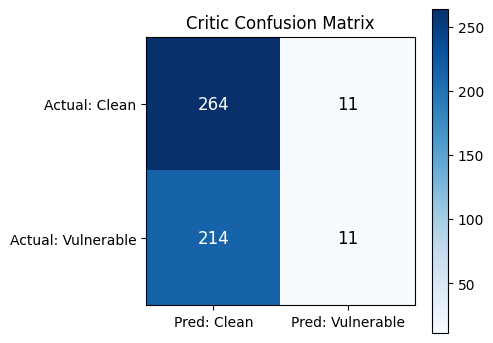

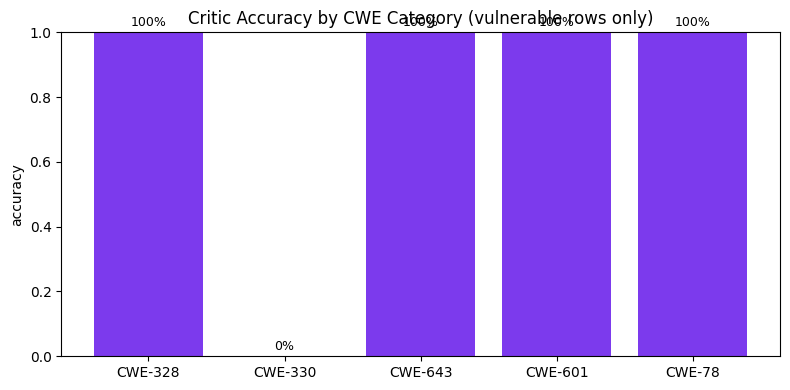

Rule coverage: 5/5 CWEs present = 100.00%

RAG Retrieval Hit@1: 23.08%
RAG Retrieval Hit@3: 30.77%



,Metric,Score
0,Critic Accuracy,55.00%
1,Critic Precision,50.00%
2,Critic Recall,4.89%
3,Critic F1,8.91%
4,Rule Coverage (CWEs present),100.00%
5,RAG Retrieval Hit@1,23.08%
6,RAG Retrieval Hit@3,30.77%
7,Eval Sample Size,500


In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ---------- 1. Run the Critic over a real test sample ----------
EVAL_N = 500
eval_df_raw = df_test.sample(n=min(EVAL_N, len(df_test)), random_state=SEED).reset_index(drop=True)

predictions = []
for _, row in eval_df_raw.iterrows():
    pred = critic(str(row[CODE_COL]))
    predictions.append({
        "true_label": bool(row[LABEL_COL]),
        "true_cwe": str(row[CWE_COL]),
        "pred_vulnerable": pred["cwe_id"] != "N/A",
        "pred_cwe": pred["cwe_id"],
    })
eval_results = pd.DataFrame(predictions)

# ---------- 2. Accuracy / Precision / Recall / F1 ----------
y_true, y_pred = eval_results["true_label"], eval_results["pred_vulnerable"]
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)

print("=" * 60)
print("CRITIC BENCHMARK —", len(eval_results), "test samples")
print("=" * 60)
print(f"Accuracy:  {acc:.2%}")
print(f"Precision: {prec:.2%}")
print(f"Recall:    {rec:.2%}")
print(f"F1 Score:  {f1:.2%}\n")

# ---------- 3. Confusion Matrix (matplotlib) ----------
cm = confusion_matrix(y_true, y_pred, labels=[False, True])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: Clean", "Pred: Vulnerable"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual: Clean", "Actual: Vulnerable"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
ax.set_title("Critic Confusion Matrix")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# ---------- 4. Per-CWE accuracy (vulnerable rows only, matplotlib) ----------
cwe_eval = eval_results[(eval_results["true_cwe"] != "unknown") & (eval_results["true_label"] == True)].copy()
cwe_eval["match"] = cwe_eval["true_cwe"] == cwe_eval["pred_cwe"]
cwe_summary = (cwe_eval.groupby("true_cwe")
               .agg(total=("match", "size"), correct=("match", "sum"))
               .assign(accuracy=lambda d: d["correct"] / d["total"])
               .sort_values("total", ascending=False).reset_index())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cwe_summary["true_cwe"], cwe_summary["accuracy"], color="#7c3aed")
ax.set_ylim(0, 1)
ax.set_ylabel("accuracy")
ax.set_title("Critic Accuracy by CWE Category (vulnerable rows only)")
for bar, acc_val in zip(bars, cwe_summary["accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{acc_val:.0%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# ---------- 5. Rule coverage ----------
covered_cwes = {r["cwe_id"] for r in CRITIC_RULES}
present_cwes = set(cwe_eval["true_cwe"].unique())
coverage_rate = len(present_cwes & covered_cwes) / len(present_cwes) if present_cwes else 0
print(f"Rule coverage: {len(present_cwes & covered_cwes)}/{len(present_cwes)} CWEs present = {coverage_rate:.2%}\n")

# ---------- 6. RAG retrieval benchmark ----------
retrieval_rows = []
for rule in CRITIC_RULES:
    guidance = retriever({"retrieval_query": rule["retrieval_query"], "cwe_id": rule["cwe_id"]}, top_k=3)
    retrieval_rows.append({
        "cwe_id": rule["cwe_id"],
        "query": rule["retrieval_query"],
        "hit@1": guidance[0]["cwe"] == rule["cwe_id"] if guidance else False,
        "hit@3": any(g["cwe"] == rule["cwe_id"] for g in guidance),
    })
rb_df = pd.DataFrame(retrieval_rows)
hit1, hit3 = rb_df["hit@1"].mean(), rb_df["hit@3"].mean()
print(f"RAG Retrieval Hit@1: {hit1:.2%}")
print(f"RAG Retrieval Hit@3: {hit3:.2%}\n")

# ---------- 7. Final benchmark summary table ----------
benchmark_summary = pd.DataFrame({
    "Metric": ["Critic Accuracy", "Critic Precision", "Critic Recall", "Critic F1",
               "Rule Coverage (CWEs present)", "RAG Retrieval Hit@1", "RAG Retrieval Hit@3", "Eval Sample Size"],
    "Score": [f"{acc:.2%}", f"{prec:.2%}", f"{rec:.2%}", f"{f1:.2%}",
              f"{coverage_rate:.2%}", f"{hit1:.2%}", f"{hit3:.2%}", len(eval_results)]
})
benchmark_summary

In [40]:
for cwe in ["CWE-330", "CWE-601", "CWE-78", "CWE-79", "CWE-643"]:
    sample = eval_df_raw[eval_df_raw[CWE_COL] == cwe].head(2)
    for _, row in sample.iterrows():
        print(f"--- {cwe} ---")
        print(row[CODE_COL][-600:])
        print()

--- CWE-330 ---
est00041", "noCookieValueSupplied"))

		bar = param + '_SafeStuff'

		import base64
		import secrets
		from helpers.utils import mysession

		num = 'BenchmarkTest00041'[13:]
		user = f'SafeToby{num}'
		cookie = f'rememberMe{num}'
		value = base64.b64encode(secrets.token_bytes(32))

		if cookie in mysession and request.cookies.get(cookie) == mysession[cookie]:
			RESPONSE += (
				f'Welcome back: {user}<br/>'
			)
		else:
			mysession[cookie] = value
			RESPONSE += (
				f'{user} has been remembered with cookie:'
				f'{cookie} whose value is: {mysession[cookie]}<br/>'
			)

		return RESPONSE



--- CWE-330 ---
another-Value'
		bar = "safe!"
		bar = map66646['keyB-66646']
		bar = map66646['keyA-66646']

		import secrets
		from helpers.utils import mysession

		num = 'BenchmarkTest00032'[13:]
		user = f'SafeRobbie{num}'
		cookie = f'rememberMe{num}'
		value = str(secrets.randbelow(2**32))

		if cookie in mysession and request.cookies.get(cookie) == mysession[cookie]:
			R

## 18. Limitations and Future Work

**Current limitations**
- The Critic is a **simple rule-based regex matcher**, not a replacement for professional SAST tools (Semgrep, CodeQL, Bandit).
- Pattern matching can produce false positives/negatives on obfuscated or syntactically unusual code.
- `CRITIC_RULES` currently covers 13 CWE categories; the dataset contains a few additional categories (e.g. XSS variants,
  insecure transport) not yet represented by a rule.
- CodeXGLUE records carry `unknown` CWE labels by design, limiting fine-grained evaluation on that subset.
- The Fixer is **template-based**, not code-generative — it explains *what* to fix, not a fully rewritten patch yet.

**Planned future work**
- Add a synthetic/paired vulnerable→fixed-code dataset for stronger Fixer supervision.
- Replace the template Fixer with an LLM-based Fixer (DeepSeek-Coder, CodeLlama, or a hosted API) that emits a real git patch.
- Improve evaluation using **LLM-as-judge**, ROUGE/BLEU against known secure fixes, and executable-code validity checks.
- Explore a neural Critic (trained on MiniLM embeddings) as a higher-recall complement to the rule-based Critic, with the
  rule-based Critic retained for CWE attribution and guidance retrieval.
- Move this logic into a FastAPI service (`/review`, `/webhook/github`) with Celery + Redis for async processing.
- Add a Streamlit dashboard and a GitHub Action that comments directly on pull requests.
- Add LLM tracing/monitoring (LangSmith or Phoenix) once an LLM-based Fixer is introduced.

### Responsible use
This project is intended strictly for **defensive security education and tooling**. It is not designed or intended
to generate exploit payloads, and any vulnerability patterns shown here exist solely to power **detection and
remediation**, never offensive use.